# 5511 - Module 5  - I am a Painter

## Setup Environment - tensorflow backend, Keras library and optimise for MacOS

In [52]:
import os
import sys
import glob
import time
from pathlib import Path
from datetime import datetime
import warnings
import numpy as np
import random
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

import platform

os.environ['KERAS_BACKEND'] = 'tensorflow'
import tensorflow as tf
from tensorflow.keras import mixed_precision

autotune = tf.data.AUTOTUNE

import keras
from keras import layers, ops
import tensorflow_datasets as tfds

# Determine if we're running locally or in Kaggle'
KAGGLE_ENV = os.path.exists('/kaggle/input')
if KAGGLE_ENV:
    print("Using Kaggle competition data")
    DATA_DIR = Path('/kaggle/input/gan-getting-started')
else:
    print("Running locally with downloaded Kaggle data")
    DATA_DIR = Path("data/gan-getting-started")

    # Set up for Apple Silicon GPU acceleration - locally I run a MacBook Pro M1
    is_macos = platform.system() == "Darwin"
    if is_macos:
        print(f"Running on macOS: {is_macos}")

        USE_MIXED_PRECISION = False  # Not always a good idea, so use variable to turn on/off

        # Enable GPU acceleration if available
        print("Metal GPU Available: ", len(tf.config.list_physical_devices('GPU')) > 0)
        if tf.config.list_physical_devices('GPU'):
            print("Using GPU acceleration with Metal")
            for gpu in tf.config.list_physical_devices('GPU'):
                tf.config.experimental.set_memory_growth(gpu, True)
        else:
            print("GPU not available, using CPU")
        # Enable mixed precision policy
        if USE_MIXED_PRECISION:
            policy = mixed_precision.Policy('mixed_float16')
        else:
            policy = mixed_precision.Policy('float32')
        mixed_precision.set_global_policy(policy)
        print(f"Mixed precision policy set to: {policy}")

# paths
OUTPUT_DIR = Path("./outputs/5511_module5")
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)
FIG_DIR = Path("./figs/5511_module5")
FIG_DIR.mkdir(exist_ok=True, parents=True)
MODEL_DIR = Path("./models/5511_module5")
MODEL_DIR.mkdir(exist_ok=True, parents=True)
# input image files (to work locally or on Kaggle)
monet_jpg_dir = DATA_DIR / "monet_jpg"
monet_tfrec_dir = DATA_DIR / "monet_tfrec"
photo_jpg_dir = DATA_DIR / "photo_jpg"
photo_tfrec_dir = DATA_DIR / "photo_tfrec"

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Python:", sys.version.split()[0])
print("TensorFlow version:", tf.__version__)
print("Keras version:", tf.keras.__version__)


Running locally with downloaded Kaggle data
Running on macOS: True
Metal GPU Available:  True
Using GPU acceleration with Metal
Mixed precision policy set to: <DTypePolicy "float32">
Python: 3.11.13
TensorFlow version: 2.19.1
Keras version: 3.11.3


In [53]:
# Set up some initial parameters - doubt I am using all of them, revisit later
orig_img_size = (256, 256)
# Size of the random crops to be used during training.
input_img_size = (256, 256, 3)
# Weights initializer for the layers.
kernel_init = keras.initializers.RandomNormal(mean=0.0, stddev=0.02)
# Gamma initializer for instance normalization.
gamma_init = keras.initializers.RandomNormal(mean=0.0, stddev=0.02)

buffer_size = 256
batch_size = 1

## 1) Problem Description

This project will generate images in the style of Monet. By using machine learning techniques, we can identify the different styles such as color pallete or brush strokes of different artists. This rpboe, involved using 2 neural networks: a generator model and a discriminator model. The generator will create the images in the style of Monet. The discriminator will try to accurately classify the real vs generated images. We are tasked to build a GAN to generate thousands of Monet style images.
We are given 300 monet paintings and 7038 photos of size 256x256. https://www.kaggle.com/competitions/gan-getting-started

## 2) Prepare the Dataset

Notes on data preparation decisions:

1) We have 7028 photos, but only 300 Monets, so we will need to use 100% of the data for training. As this is unsupervised learning, it is not an issue to not holdout validation/test sets. Instead, I will use sampling to provide a smaller dataset for monitoring the results.
2) I have used repeat() to make it go on indefinitely and if desired use all the available training photos with randomly selected Monets from the 300. This means that I must remember to use epochs= xx and steps per epoch= yy for it to work.
3) I have limited augmentation to random flipping and resizing.
4) I have used tfrec to load the data. I believe it offers large performance enhancements during training over loading from the jpegs.
5) The train_dataset is pre-zipped, which I hope will make life simpler as I progress.

The last step is to print some basic stats about the train_dataset created and check a few sample images, just to make sure everything is working as expected.
```
cycle_gan_model.fit(
    train_dataset,
    epochs=10,
    steps_per_epoch=100,  # This is what controls training length
    callbacks=[plotter, model_checkpoint_callback],
)
```

In [54]:
def create_cyclegan_dataset(photo_files, monet_files, img_size=(256, 256), batch_size=batch_size):
    """Optimized dataset for CycleGAN training"""

    if not monet_files or not photo_files:
        raise ValueError("Both monet_files and photo_files must be non-empty lists")

    print(f"Creating dataset with {len(monet_files)} Monet files and {len(photo_files)} photo files")

    def parse_and_resize(record):
        example = tf.io.parse_single_example(record, {
            'image': tf.io.FixedLenFeature([], tf.string)
        })
        image = tf.io.decode_jpeg(example['image'], channels=3)
        image = tf.image.resize(image, img_size)
        image = tf.image.random_flip_left_right(image)
        image = tf.cast(image, tf.float32) / 127.5 - 1.0  # Normalize to [-1, 1]
        return image

    monet_ds = (tf.data.TFRecordDataset(monet_files, num_parallel_reads=tf.data.AUTOTUNE)
                .map(parse_and_resize, num_parallel_calls=tf.data.AUTOTUNE)
                .shuffle(1000)
                .repeat()
                .batch(batch_size)  # Made this configurable
                .prefetch(tf.data.AUTOTUNE))

    photo_ds = (tf.data.TFRecordDataset(photo_files, num_parallel_reads=tf.data.AUTOTUNE)
                .map(parse_and_resize, num_parallel_calls=tf.data.AUTOTUNE)
                .shuffle(1000)
                .repeat()
                .batch(batch_size)
                .prefetch(tf.data.AUTOTUNE))

    # Add prefetch to the final zipped dataset
    return tf.data.Dataset.zip((photo_ds, monet_ds)).prefetch(tf.data.AUTOTUNE)

# Load TFRecord datasets
monet_files = tf.io.gfile.glob(f"{monet_tfrec_dir}/*.tfrec")
photo_files = tf.io.gfile.glob(f"{photo_tfrec_dir}/*.tfrec")

# given only 300 Monet images, use all data for training
train_dataset = create_cyclegan_dataset(monet_files, photo_files)

# For monitoring, just take a few batches from the training data
monitor_dataset = train_dataset.take(5)  # Take first 5 batches for visualization


Creating dataset with 20 Monet files and 5 photo files


=== Dataset Summary ===
Monet batch shape: (1, 256, 256, 3)
Photo batch shape: (1, 256, 256, 3)
Monet batch dtype: <dtype: 'float32'>
Photo batch dtype: <dtype: 'float32'>

Value ranges:
Monet batch - min: -1.000, max: 0.992
Photo batch - min: -1.000, max: 1.000

Counting total batches...
First 100 batches counted (dataset uses .repeat() so it's infinite)

Approximate memory per batch: 1.50 MB

Visualising some samples...


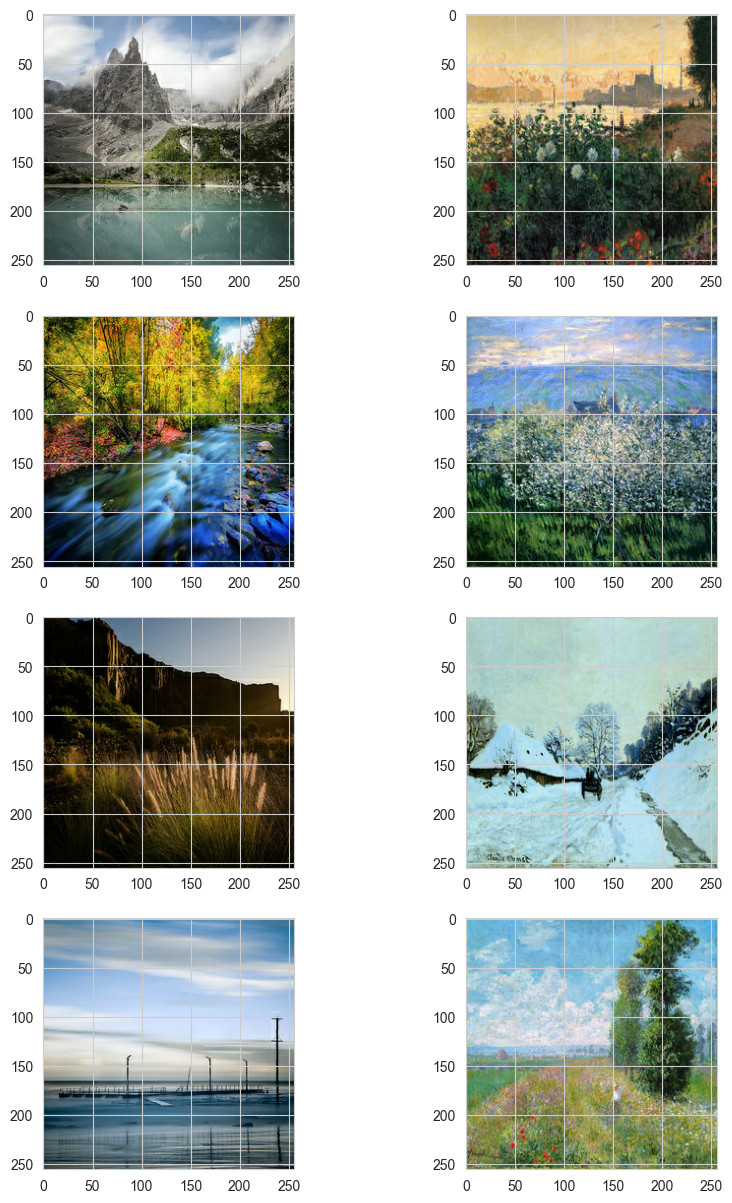

In [55]:
# Basic dataset info
print("=== Dataset Summary ===")

# 1. Check a single batch to understand the structure
sample_batch = next(iter(train_dataset))
monet_batch, photo_batch = sample_batch
print(f"Monet batch shape: {monet_batch.shape}")
print(f"Photo batch shape: {photo_batch.shape}")
print(f"Monet batch dtype: {monet_batch.dtype}")
print(f"Photo batch dtype: {photo_batch.dtype}")

# 2. Check value ranges (should be [-1, 1] after normalization)
print(f"\nValue ranges:")
print(f"Monet batch - min: {tf.reduce_min(monet_batch):.3f}, max: {tf.reduce_max(monet_batch):.3f}")
print(f"Photo batch - min: {tf.reduce_min(photo_batch):.3f}, max: {tf.reduce_max(photo_batch):.3f}")

# 3. Estimate total number of batches (this will consume the dataset, so recreate after)
print(f"\nCounting total batches...")
batch_count = 0
for batch in train_dataset.take(100):  # Take first 100 to avoid infinite loop
    batch_count += 1
print(f"First 100 batches counted (dataset uses .repeat() so it's infinite)")

# 4. Memory usage per batch (approximate)
batch_size_bytes = monet_batch.numpy().nbytes + photo_batch.numpy().nbytes
print(f"\nApproximate memory per batch: {batch_size_bytes / (1024**2):.2f} MB")

# 5. Visualise some samples
print(f"\nVisualising some samples...")
_, ax = plt.subplots(4, 2, figsize=(10, 15))
for i, samples in enumerate(train_dataset.take(4)):
    monet = (((samples[0][0] * 127.5) + 127.5).numpy()).astype(np.uint8)
    photo = (((samples[1][0] * 127.5) + 127.5).numpy()).astype(np.uint8)
    ax[i, 0].imshow(photo)
    ax[i, 1].imshow(monet)
plt.show()

## Building blocks used in the CycleGAN generators and discriminators

In [56]:
class ReflectionPadding2D(layers.Layer):
    """Implements Reflection Padding as a layer.

    Args:
        padding(tuple): Amount of padding for the
        spatial dimensions.

    Returns:
        A padded tensor with the same type as the input tensor.
    """

    def __init__(self, padding=(1, 1), **kwargs):
        self.padding = tuple(padding)
        super().__init__(**kwargs)

    def call(self, input_tensor, mask=None):
        padding_width, padding_height = self.padding
        padding_tensor = [
            [0, 0],
            [padding_height, padding_height],
            [padding_width, padding_width],
            [0, 0],
        ]
        return ops.pad(input_tensor, padding_tensor, mode="REFLECT")


def residual_block(
    x,
    activation,
    kernel_initializer=kernel_init,
    kernel_size=(3, 3),
    strides=(1, 1),
    padding="valid",
    gamma_initializer=gamma_init,
    use_bias=False,
):
    dim = x.shape[-1]
    input_tensor = x

    x = ReflectionPadding2D()(input_tensor)
    x = layers.Conv2D(
        dim,
        kernel_size,
        strides=strides,
        kernel_initializer=kernel_initializer,
        padding=padding,
        use_bias=use_bias,
    )(x)
    x = keras.layers.GroupNormalization(groups=1, gamma_initializer=gamma_initializer)(
        x
    )
    x = activation(x)

    x = ReflectionPadding2D()(x)
    x = layers.Conv2D(
        dim,
        kernel_size,
        strides=strides,
        kernel_initializer=kernel_initializer,
        padding=padding,
        use_bias=use_bias,
    )(x)
    x = keras.layers.GroupNormalization(groups=1, gamma_initializer=gamma_initializer)(
        x
    )
    x = layers.add([input_tensor, x])
    return x


def downsample(
    x,
    filters,
    activation,
    kernel_initializer=kernel_init,
    kernel_size=(3, 3),
    strides=(2, 2),
    padding="same",
    gamma_initializer=gamma_init,
    use_bias=False,
):
    x = layers.Conv2D(
        filters,
        kernel_size,
        strides=strides,
        kernel_initializer=kernel_initializer,
        padding=padding,
        use_bias=use_bias,
    )(x)
    x = keras.layers.GroupNormalization(groups=1, gamma_initializer=gamma_initializer)(
        x
    )
    if activation:
        x = activation(x)
    return x


def upsample(
    x,
    filters,
    activation,
    kernel_size=(3, 3),
    strides=(2, 2),
    padding="same",
    kernel_initializer=kernel_init,
    gamma_initializer=gamma_init,
    use_bias=False,
):
    x = layers.Conv2DTranspose(
        filters,
        kernel_size,
        strides=strides,
        padding=padding,
        kernel_initializer=kernel_initializer,
        use_bias=use_bias,
    )(x)
    x = keras.layers.GroupNormalization(groups=1, gamma_initializer=gamma_initializer)(
        x
    )
    if activation:
        x = activation(x)
    return x

## Build the Generators

The generator consists of downsampling blocks: nine residual blocks and upsampling blocks. The structure of the generator is the following:
```
c7s1-64 ==> Conv block with `relu` activation, filter size of 7
d128 ====|
         |-> 2 downsampling blocks
d256 ====|
R256 ====|
R256     |
R256     |
R256     |
R256     |-> 9 residual blocks
R256     |
R256     |
R256     |
R256 ====|
u128 ====|
         |-> 2 upsampling blocks
u64  ====|
c7s1-3 => Last conv block with `tanh` activation, filter size of 7.
```


In [57]:
def get_resnet_generator(
    filters=64,
    num_downsampling_blocks=2,
    num_residual_blocks=9,
    num_upsample_blocks=2,
    gamma_initializer=gamma_init,
    name=None,
):
    img_input = layers.Input(shape=input_img_size, name=name + "_img_input")
    x = ReflectionPadding2D(padding=(3, 3))(img_input)
    x = layers.Conv2D(filters, (7, 7), kernel_initializer=kernel_init, use_bias=False)(
        x
    )
    x = keras.layers.GroupNormalization(groups=1, gamma_initializer=gamma_initializer)(
        x
    )
    x = layers.Activation("relu")(x)

    # Downsampling
    for _ in range(num_downsampling_blocks):
        filters *= 2
        x = downsample(x, filters=filters, activation=layers.Activation("relu"))

    # Residual blocks
    for _ in range(num_residual_blocks):
        x = residual_block(x, activation=layers.Activation("relu"))

    # Upsampling
    for _ in range(num_upsample_blocks):
        filters //= 2
        x = upsample(x, filters, activation=layers.Activation("relu"))

    # Final block
    x = ReflectionPadding2D(padding=(3, 3))(x)
    x = layers.Conv2D(3, (7, 7), padding="valid")(x)
    x = layers.Activation("tanh")(x)

    model = keras.models.Model(img_input, x, name=name)
    return model


## Build the Discriminators

The discriminators implement the following architecture:
`C64->C128->C256->C512`

In [58]:
def get_discriminator(
    filters=64, kernel_initializer=kernel_init, num_downsampling=3, name=None
):
    img_input = layers.Input(shape=input_img_size, name=name + "_img_input")
    x = layers.Conv2D(
        filters,
        (4, 4),
        strides=(2, 2),
        padding="same",
        kernel_initializer=kernel_initializer,
    )(img_input)
    x = layers.LeakyReLU(0.2)(x)

    num_filters = filters
    for num_downsample_block in range(3):
        num_filters *= 2
        if num_downsample_block < 2:
            x = downsample(
                x,
                filters=num_filters,
                activation=layers.LeakyReLU(0.2),
                kernel_size=(4, 4),
                strides=(2, 2),
            )
        else:
            x = downsample(
                x,
                filters=num_filters,
                activation=layers.LeakyReLU(0.2),
                kernel_size=(4, 4),
                strides=(1, 1),
            )

    x = layers.Conv2D(
        1, (4, 4), strides=(1, 1), padding="same", kernel_initializer=kernel_initializer
    )(x)

    model = keras.models.Model(inputs=img_input, outputs=x, name=name)
    return model

In [59]:
# Get the generators
gen_G = get_resnet_generator(name="generator_G")
gen_F = get_resnet_generator(name="generator_F")

# Get the discriminators
disc_X = get_discriminator(name="discriminator_X")
disc_Y = get_discriminator(name="discriminator_Y")

## Build the CycleGAN model

In [60]:
class CycleGan(keras.Model):
    def __init__(
        self,
        generator_G,
        generator_F,
        discriminator_X,
        discriminator_Y,
        lambda_cycle=10.0,
        lambda_identity=0.5,
    ):
        super().__init__()
        self.gen_G = generator_G
        self.gen_F = generator_F
        self.disc_X = discriminator_X
        self.disc_Y = discriminator_Y
        self.lambda_cycle = lambda_cycle
        self.lambda_identity = lambda_identity

    def call(self, inputs):
        return (
            self.disc_X(inputs),
            self.disc_Y(inputs),
            self.gen_G(inputs),
            self.gen_F(inputs),
        )

    def compile(
        self,
        gen_G_optimizer,
        gen_F_optimizer,
        disc_X_optimizer,
        disc_Y_optimizer,
        gen_loss_fn,
        disc_loss_fn,
    ):
        super().compile()
        self.gen_G_optimizer = gen_G_optimizer
        self.gen_F_optimizer = gen_F_optimizer
        self.disc_X_optimizer = disc_X_optimizer
        self.disc_Y_optimizer = disc_Y_optimizer
        self.generator_loss_fn = gen_loss_fn
        self.discriminator_loss_fn = disc_loss_fn
        self.cycle_loss_fn = keras.losses.MeanAbsoluteError()
        self.identity_loss_fn = keras.losses.MeanAbsoluteError()

    def train_step(self, batch_data):
        # x is photo and y is Monet
        real_x, real_y = batch_data

        # For CycleGAN, we need to calculate different
        # kinds of losses for the generators and discriminators.
        # We will perform the following steps here:
        #
        # 1. Pass real images through the generators and get the generated images
        # 2. Pass the generated images back to the generators to check if we
        #    can predict the original image from the generated image.
        # 3. Do an identity mapping of the real images using the generators.
        # 4. Pass the generated images in 1) to the corresponding discriminators.
        # 5. Calculate the generators total loss (adversarial + cycle + identity)
        # 6. Calculate the discriminators loss
        # 7. Update the weights of the generators
        # 8. Update the weights of the discriminators
        # 9. Return the losses in a dictionary

        with tf.GradientTape(persistent=True) as tape:
            # photo to fake Monet -> x2y
            fake_y = self.gen_G(real_x, training=True)
            # Monet to fake photo -> y2x
            fake_x = self.gen_F(real_y, training=True)

            # Cycle (Photo to fake Monet to fake photo): x -> y -> x
            cycled_x = self.gen_F(fake_y, training=True)
            # Cycle (Monet to fake photo to fake Monet) y -> x -> y
            cycled_y = self.gen_G(fake_x, training=True)

            # Identity mapping
            same_x = self.gen_F(real_x, training=True)
            same_y = self.gen_G(real_y, training=True)

            # Discriminator output
            disc_real_x = self.disc_X(real_x, training=True)
            disc_fake_x = self.disc_X(fake_x, training=True)

            disc_real_y = self.disc_Y(real_y, training=True)
            disc_fake_y = self.disc_Y(fake_y, training=True)

            # Generator adversarial loss
            gen_G_loss = self.generator_loss_fn(disc_fake_y)
            gen_F_loss = self.generator_loss_fn(disc_fake_x)

            # Generator cycle loss
            cycle_loss_G = self.cycle_loss_fn(real_y, cycled_y) * self.lambda_cycle
            cycle_loss_F = self.cycle_loss_fn(real_x, cycled_x) * self.lambda_cycle

            # Generator identity loss
            id_loss_G = (
                self.identity_loss_fn(real_y, same_y)
                * self.lambda_cycle
                * self.lambda_identity
            )
            id_loss_F = (
                self.identity_loss_fn(real_x, same_x)
                * self.lambda_cycle
                * self.lambda_identity
            )

            # Total generator loss
            total_loss_G = gen_G_loss + cycle_loss_G + id_loss_G
            total_loss_F = gen_F_loss + cycle_loss_F + id_loss_F

            # Discriminator loss
            disc_X_loss = self.discriminator_loss_fn(disc_real_x, disc_fake_x)
            disc_Y_loss = self.discriminator_loss_fn(disc_real_y, disc_fake_y)

        # Get the gradients for the generators
        grads_G = tape.gradient(total_loss_G, self.gen_G.trainable_variables)
        grads_F = tape.gradient(total_loss_F, self.gen_F.trainable_variables)

        # Get the gradients for the discriminators
        disc_X_grads = tape.gradient(disc_X_loss, self.disc_X.trainable_variables)
        disc_Y_grads = tape.gradient(disc_Y_loss, self.disc_Y.trainable_variables)

        # Update the weights of the generators
        self.gen_G_optimizer.apply_gradients(
            zip(grads_G, self.gen_G.trainable_variables)
        )
        self.gen_F_optimizer.apply_gradients(
            zip(grads_F, self.gen_F.trainable_variables)
        )

        # Update the weights of the discriminators
        self.disc_X_optimizer.apply_gradients(
            zip(disc_X_grads, self.disc_X.trainable_variables)
        )
        self.disc_Y_optimizer.apply_gradients(
            zip(disc_Y_grads, self.disc_Y.trainable_variables)
        )

        return {
            "G_loss": total_loss_G,
            "F_loss": total_loss_F,
            "D_X_loss": disc_X_loss,
            "D_Y_loss": disc_Y_loss,
        }

## Create a callback that periodically saves generated images

In [61]:
class GANMonitor(keras.callbacks.Callback):
    """A callback to generate and save images after each epoch"""

    def __init__(self, num_img=4):
        self.num_img = num_img

    def on_epoch_end(self, epoch, logs=None):
        _, ax = plt.subplots(4, 2, figsize=(12, 12))
        for i, (monet_img, photo_img) in enumerate(train_dataset.take(self.num_img)):
            prediction = self.model.gen_G(photo_img)[0].numpy()
            prediction = (prediction * 127.5 + 127.5).astype(np.uint8)
            img = (photo_img[0] * 127.5 + 127.5).numpy().astype(np.uint8)

            ax[i, 0].imshow(img)
            ax[i, 1].imshow(prediction)
            ax[i, 0].set_title("Input image")
            ax[i, 1].set_title("Translated image")
            ax[i, 0].axis("off")
            ax[i, 1].axis("off")

            prediction = keras.utils.array_to_img(prediction)
            prediction.save(FIG_DIR / f"generated_img_{i}_{epoch + 1}.png")
        plt.show()
        plt.close()

## Train the end-to-end Model

In [62]:
# Loss function for evaluating adversarial loss
adv_loss_fn = keras.losses.MeanSquaredError()

# Define the loss function for the generators
def generator_loss_fn(fake):
    fake_loss = adv_loss_fn(ops.ones_like(fake), fake)
    return fake_loss


# Define the loss function for the discriminators
def discriminator_loss_fn(real, fake):
    real_loss = adv_loss_fn(ops.ones_like(real), real)
    fake_loss = adv_loss_fn(ops.zeros_like(fake), fake)
    return (real_loss + fake_loss) * 0.5


# Create cycle gan model
cycle_gan_model = CycleGan(
    generator_G=gen_G, generator_F=gen_F, discriminator_X=disc_X, discriminator_Y=disc_Y
)

# Compile the model
cycle_gan_model.compile(
    gen_G_optimizer=keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5),
    gen_F_optimizer=keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5),
    disc_X_optimizer=keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5),
    disc_Y_optimizer=keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5),
    gen_loss_fn=generator_loss_fn,
    disc_loss_fn=discriminator_loss_fn,
)

# BUILD the model by calling it on sample data
cycle_gan_model.build([(None, 256, 256, 3), (None, 256, 256, 3)])

# Callbacks
plotter = GANMonitor()
checkpoint_filepath = "./model_checkpoints/cyclegan_checkpoints.weights.h5"
model_checkpoint_callback = keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath, save_weights_only=True
)


In [ ]:
# Train the model
cycle_gan_model.fit(
    train_dataset,
    epochs=2,
    steps_per_epoch=100,  # This is what controls training length
    callbacks=[plotter, model_checkpoint_callback],
)


Epoch 1/2
 20/100 ━━━━━━━━━━━━━━━━━━━━ 2:39 2s/step - D_X_loss: 0.2168 - D_Y_loss: 0.2273 - F_loss: 6.5248 - G_loss: 8.0943

## Test the Performance of the Model

Weights loaded successfully


2025-10-09 14:17:36.306619: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


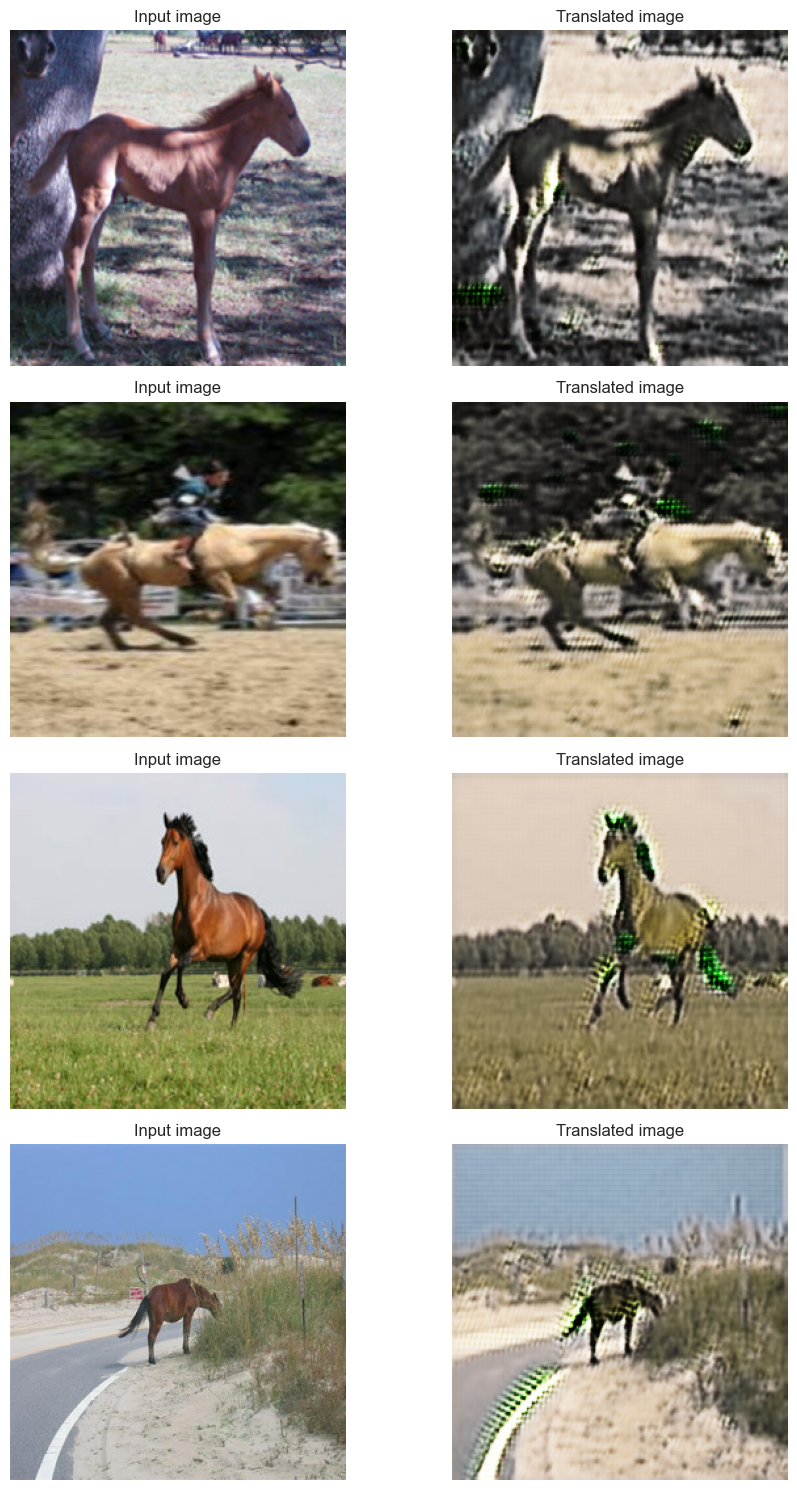

In [23]:
# Once the weights are loaded, we will take a few samples from the test data and check the model's performance.

# Load the checkpoints
cycle_gan_model.load_weights(checkpoint_filepath)
print("Weights loaded successfully")

_, ax = plt.subplots(4, 2, figsize=(10, 15))
for i, (monet_img, photo_img) in enumerate(train_dataset.take(4)):
    prediction = cycle_gan_model.gen_G(photo_img, training=False)[0].numpy()
    prediction = (prediction * 127.5 + 127.5).astype(np.uint8)
    img = (photo_img[0] * 127.5 + 127.5).numpy().astype(np.uint8)

    ax[i, 0].imshow(img)
    ax[i, 1].imshow(prediction)
    ax[i, 0].set_title("Input image")
    ax[i, 0].set_title("Input image")
    ax[i, 1].set_title("Translated image")
    ax[i, 0].axis("off")
    ax[i, 1].axis("off")

    prediction = keras.utils.array_to_img(prediction)
    prediction.save(os.path.join(FIG_DIR, "predicted_img_{i}.png".format(i=i)))
plt.tight_layout()
plt.show()